In [58]:
import os
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import shap

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from collections import Counter

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import nibabel as nib
from scipy.spatial import cKDTree 

An data overview for the classification below. 

Number of image arrays: 1841
Number of mask arrays: 1841

Images without masks: set()
Masks without images: set()

--- IMAGE SIZE STATS ---
Avg width: 244.41716458446496
Avg height: 217.58609451385118
Width range: (154, 512)
Height range: (154, 428)
Unique channel counts: {1}

--- MASK UNIQUE VALUES (classes) ---
Counter({np.float64(0.0): 1841, np.float64(2.0): 1828, np.float64(3.0): 1808, np.float64(1.0): 1558})


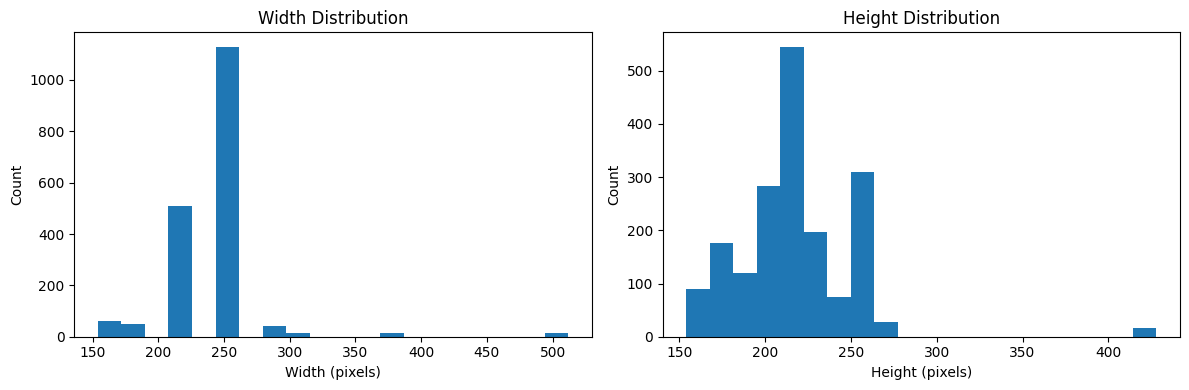

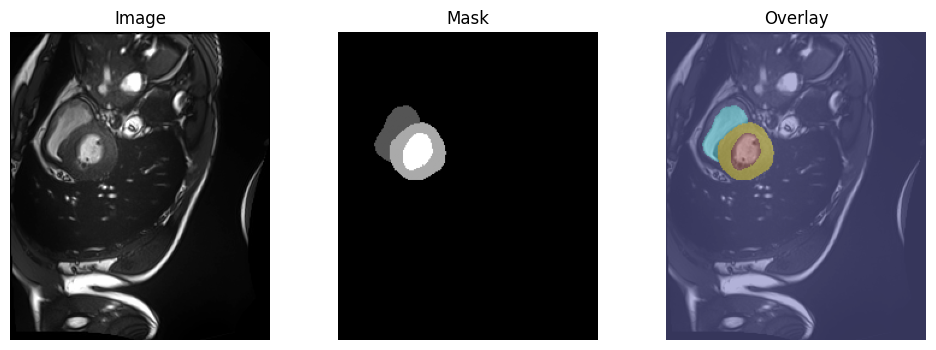

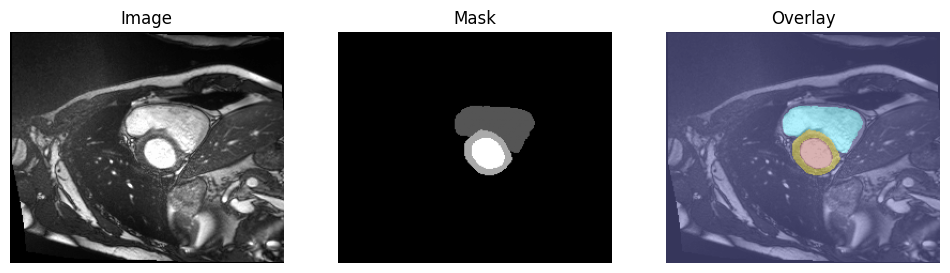

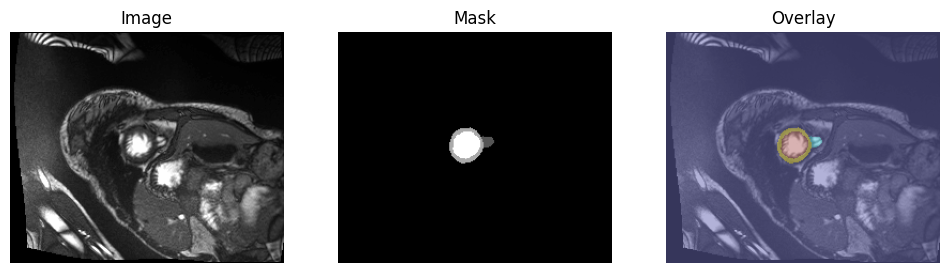

In [59]:
img_dir = "./processed_data/processed_data/images"
mask_dir = "./processed_data/processed_data/masks"

# ----------------------------------------
# 1. LOAD ALL .npy FILES
# ----------------------------------------
all_images = sorted(glob.glob(os.path.join(img_dir, "*.npy")))
all_masks = sorted(glob.glob(os.path.join(mask_dir, "*.npy")))

print("Number of image arrays:", len(all_images))
print("Number of mask arrays:", len(all_masks))

# ----------------------------------------
# 2. MATCH IMAGE–MASK PAIRS
# ----------------------------------------
img_names = set([os.path.splitext(os.path.basename(f))[0] for f in all_images])
mask_names = set([os.path.splitext(os.path.basename(f))[0] for f in all_masks])

print("\nImages without masks:", img_names - mask_names)
print("Masks without images:", mask_names - img_names)

# ----------------------------------------
# 3. SHAPE + STATS COLLECTION
# ----------------------------------------
heights = []
widths = []
channels = []
mask_value_counter = Counter()

for img_file in all_images:
    base = os.path.splitext(os.path.basename(img_file))[0]
    mask_file = os.path.join(mask_dir, base + ".npy")

    img = np.load(img_file)

    # store dimensions
    if img.ndim == 2:
        h, w = img.shape
        c = 1
    else:
        h, w, c = img.shape

    heights.append(h)
    widths.append(w)
    channels.append(c)

    # load and analyze mask
    if os.path.exists(mask_file):
        mask = np.load(mask_file)
        unique_vals = np.unique(mask)
        mask_value_counter.update(unique_vals)

# ----------------------------------------
# 4. PRINT BASIC STATS
# ----------------------------------------
print("\n--- IMAGE SIZE STATS ---")
print("Avg width:", np.mean(widths))
print("Avg height:", np.mean(heights))
print("Width range:", (min(widths), max(widths)))
print("Height range:", (min(heights), max(heights)))
print("Unique channel counts:", set(channels))

print("\n--- MASK UNIQUE VALUES (classes) ---")
print(mask_value_counter)

# ----------------------------------------
# 5. HISTOGRAMS OF DIMENSIONS
# ----------------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# ----------------------------------------
# 6. SHOW RANDOM EXAMPLES (IMAGE + MASK + OVERLAY)
# ----------------------------------------
def show_random(n=3):
    sample = random.sample(all_images, n)

    for img_file in sample:
        base = os.path.splitext(os.path.basename(img_file))[0]
        mask_file = os.path.join(mask_dir, base + ".npy")

        img = np.load(img_file)
        mask = np.load(mask_file)

        # if grayscale, expand to 3 channels for overlay
        if img.ndim == 2:
            img_display = np.stack([img]*3, axis=-1)
        else:
            img_display = img

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img_display, cmap="gray")
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(img_display, alpha=0.7)
        plt.imshow(mask, cmap="jet", alpha=0.3)
        plt.title("Overlay")
        plt.axis("off")

        plt.show()

show_random(3) 

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

Using device: cpu


### Classification


Overwiew:

This pipeline performs cardiac disease classification using the ACDC dataset. Instead of training a segmentation model, it directly uses the ground truth segmentations to extract clinically meaningful features.


Pipeline Steps
1. Load patient metadata (diagnosis, height, weight, ED/ES frames)
2. Load ground truth segmentation masks (_gt.nii.gz)
3. Compute volumetric features (RV, LV, MYO)
4. Compute ejection fraction (EF)
5. Train classification models (Random Forest, XGBoost, CatBoost)
6. Evaluate with GroupKFold cross-validation
6. Interpret results using SHAP

In [61]:
# 1. DATASET INLADEN

class ACDCDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.target_size = (512, 512)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.load(self.image_paths[idx])
        mask = np.load(self.mask_paths[idx])

        img = np.stack((img, img, img), axis=0)
        mask = np.expand_dims(mask, axis=0)

        img_t = torch.tensor(img, dtype=torch.float32)
        mask_t = torch.tensor(mask, dtype=torch.long)

        img_t = F.interpolate(img_t.unsqueeze(0), size=self.target_size, mode="bilinear", align_corners=False).squeeze(0)
        mask_t = F.interpolate(mask_t.unsqueeze(0).float(), size=self.target_size, mode="nearest").squeeze(0).long()

        return img_t, mask_t

Maps diagnosis labels to numeric classes for machine learning. 

Labels for the classification:
- NOR (normal)
- MINF (myocardial infarction)
- DCM (dilated cardiomyopathy)
- HCM (hypertrophic cardiomyopathy)
- RV (right ventricular abnormality)

It is a feature-based approach, in which clinically relevant features are first extracted from the segmentations, after which a classical machine learning model is trained.

It is based on volumetric measurements and derived quantities such as the ejection fraction (EF). 

ACDC training set convention:

- patient001-020 = NOR
- patient021-040 = MINF
- patient041-060 = DCM
- patient061-080 = HCM
- patient081-100 = RV

In [62]:
# 2. LABEL MAPPING

GROUP_TO_LABEL = {"NOR":0, "MINF":1, "DCM":2, "HCM":3, "RV":4}

Feature Extraction from Segmentations

For the classification task, features are extracted from the cardiac segmentation masks. These are based on the end-diastolic (ED) and end-systolic (ES) phases.

ED corresponds to the phase of maximum filling of the heart, while ES represents the phase of maximum contraction. 

The difference between these volumes is used to compute the ejection fraction (EF): EF = (ED − ES) / ED

These features are clinically related to different cardiac pathologies:

- DCM (Dilated Cardiomyopathy): enlarged ventricle → low EF
- HCM (Hypertrophic Cardiomyopathy): thickened myocardium
- RV abnormality: abnormal right ventricle

By using these physically interpretable features, the model can effectively distinguish between the different classes.

In [63]:
# 2. FEATURE-EXTRACTIE FUNCTIES

#Defines segmentation labels in the ground truth masks.
CLASSES = (1, 2, 3)  # 1=RV, 2=Myocardium, 3=LV 


def compute_ejection_fraction(ed_volume, es_volume):
    return 0.0 if ed_volume == 0 else (ed_volume - es_volume) / ed_volume # computes the ejection fraction (EF)


def extract_features_ED_ES(mask_ed, mask_es, spacing_ed, spacing_es):
    """
    Bereken volumetrische features + ejection fractions uit ED en ES masks.

    Labels:
    1 = RV
    2 = LV
    3 = Myocardium
    """
    mask_ed = np.asarray(mask_ed)
    mask_es = np.asarray(mask_es)

    # Voxel volume (mm³)
    voxel_vol_ed = spacing_ed[0] * spacing_ed[1] * spacing_ed[2]
    voxel_vol_es = spacing_es[0] * spacing_es[1] * spacing_es[2]

    feats = []
    volumes_ed = {}
    volumes_es = {}

    # Calculates volumes for RV, MYO, LV
    for cls in CLASSES:
        vol_ed = np.sum(mask_ed == cls) * voxel_vol_ed
        vol_es = np.sum(mask_es == cls) * voxel_vol_es

        volumes_ed[cls] = vol_ed
        volumes_es[cls] = vol_es

        feats.extend([vol_ed, vol_es])

    # Ejection fractions voor RV en LV
    feats.extend([
        compute_ejection_fraction(volumes_ed[1], volumes_es[1]),  # RV EF
        compute_ejection_fraction(volumes_ed[3], volumes_es[3]),  # LV EF
    ])

    return np.asarray(feats, dtype=np.float32), volumes_ed, volumes_es # output: feature vector + volumes

This provides an overview of the volumes in mL of the RV, LV, and MYO of the ED and ES phases.

In [64]:
print("RV ED volume (mL):", volumes_ed[1] / 1000)
print("LV ED volume (mL):", volumes_ed[2] / 1000)
print("MYO ED volume (mL):", volumes_ed[3] / 1000)

print("RV ES volume (mL):", volumes_es[1] / 1000)
print("LV ES volume (mL):", volumes_es[2] / 1000)
print("MYO ES volume (mL):", volumes_es[3] / 1000)

RV ED volume (mL): 185.50915992736816
LV ED volume (mL): 68.698119140625
MYO ED volume (mL): 71.69327403259277
RV ES volume (mL): 112.63859957885742
LV ES volume (mL): 81.94259019470215
MYO ES volume (mL): 30.193931396484373


In this step, a custom PyTorch Dataset is defined to prepare the input for the classification model.

The dataset does not load raw MRI images or segmentation masks directly. Instead, it operates on precomputed features that were extracted earlier from the ground truth segmentations.
Each sample consists of:
- A feature vector containing volumetric measurements and ejection fractions
- Patient-specific metadata (height and weight)
- A corresponding label (diagnosis class)

The dataset combines the extracted features with the patient metadata into a single input vector. It also converts the data into PyTorch tensors, ensuring it can be efficiently used during model training and evaluation.

In [25]:
# 3. DATASET VOOR CLASSIFICATIE

# Combines extracted features with patient metadata (height, weight) for training.
class ACDCClassificationDataset(Dataset): 
    def __init__(self, features, patient_info, labels):
        self.features = features
        self.patient_info = patient_info
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = np.concatenate((self.features[idx], self.patient_info[idx]))
        y = self.labels[idx]

        return (
            torch.as_tensor(x, dtype=torch.float32),
            torch.as_tensor(y, dtype=torch.long),
        )

A neural network is defined for the classification task.

The model takes a feature vector as input, consisting of:
- volumetric measurements
- ejection fractions (EF)
- patient-specific information (e.g., height and weight)

It learns to map these features to one of the five diagnostic classes.

The network is a multi-layer perceptron (MLP) composed of several fully connected layers with ReLU activation functions. A dropout layer is included to reduce overfitting during training.

The final output layer produces a set of scores (logits), one for each class, which are used to determine the predicted diagnosis.

In [26]:
# 4. MLP CLASSIFIER

class HeartDiseaseClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=5):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.network(x)

The metadata for each patient is read from the Info.cfg file.

The following information is extracted:
- the diagnosis group (label)
- patient-specific features (height and weight)
- the ED and ES frame indices (cardiac phases)

The diagnosis group is converted into a numerical label using a predefined mapping. The remaining values are processed and formatted for use in the subsequent feature extraction and classification steps.

In [27]:
# 5. LABEL + PATIENT INFO + ED/ES FRAMES

def extract_label_from_info(patient_path):
    cfg_path = os.path.join(patient_path, "Info.cfg")

    info = {
        "Group": None,
        "Height": None,
        "Weight": None,
        "ED": None,
        "ES": None,
    }

    with open(cfg_path, "r") as f:
        for line in f:
            key, value = map(str.strip, line.split(":", 1))

            if key in info:
                info[key] = value

    # Validation
    if any(v is None for v in info.values()):
        raise ValueError(f"Info.cfg incompleet in {patient_path}")

    group = GROUP_TO_LABEL[info["Group"]]
    height = float(info["Height"])
    weight = float(info["Weight"])
    ED = int(info["ED"])
    ES = int(info["ES"])

    patient_features = np.array([height, weight], dtype=np.float32)

    return group, patient_features, ED, ES

The classification model is trained using the extracted features.

The pipeline includes:

- creating a dataset and dataloader for efficient batching
- initializing the MLP model
- defining an optimizer (Adam) and a loss function (CrossEntropyLoss)

During training:
- batches of data are passed through the model (forward pass)
- the prediction error is computed using the loss function
- backpropagation is applied to update the model weights

This process is repeated over multiple epochs, allowing the model to learn how to predict the correct diagnosis class.

In [28]:
# 6. TRAINING LOOP

def train_classification_model(feature_list, patient_info, labels, epochs=30, batch_size=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training op device: {device}")

    dataset = ACDCClassificationDataset(feature_list, patient_info, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    input_dim = feature_list[0].shape[0] + 2
    model = HeartDiseaseClassifier(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataloader):.4f}")

    return model

The trained model is evaluated on a validation set using the same dataset structure, but without performing any training.

During evaluation:
- the model is set to evaluation mode
- predictions are generated for each batch
- the predicted labels are compared with the ground truth labels

Model performance is measured using accuracy, defined as the percentage of correctly classified patients.

In [29]:
# 7. VALIDATIE

def evaluate_classification(model, feature_list, patient_info, labels):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = ACDCClassificationDataset(feature_list, patient_info, labels)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=False)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy*100:.2f}%")
    return accuracy

This function is used to load medical imaging data stored in NIfTI (.nii.gz) format.

It performs the following steps:
- loads the image file from disk
- converts the image data into a NumPy array
- extracts the voxel spacing (spatial resolution) from the file header

The voxel spacing is important for converting voxel counts into real-world volumes (mm³) during feature extraction.

In [55]:
def load_nifti(path):
    img = nib.load(path)
    data = img.get_fdata().astype(np.float32)
    spacing = img.header.get_zooms()  # (sx, sy, sz)
    return data, spacing

The dataset is first constructed by iterating over all patient folders. For each patient:
- the diagnosis label and metadata (height, weight, ED/ES frames) are extracted
- the corresponding ground truth segmentation masks (_gt.nii.gz) for ED and ES are loaded
- volumetric features and ejection fractions are computed

These features are stored together with the patient labels and metadata.

After assembling the dataset, it is split into training and test sets using GroupShuffleSplit.

Why group-based splitting?

Since all samples belonging to the same patient are highly correlated, the split is performed at the patient level:
- prevents data leakage
- ensures a fair evaluation

Without this step, the model could see data from the same patient in both training and test sets, leading to overly optimistic performance estimates.

In [31]:
# 8. Data preperation and Train-Test Split

root_dir = "./training/training"  # folder waarin patient001, patient002 etc. zit
patient_folders = sorted([
    os.path.join(root_dir, f) for f in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, f))
])

print("Voorbeeld patient folders:", patient_folders[:3]) # test 


# Collect all files and information

all_features, all_labels, all_patient_info = [], [], []

for patient_path in patient_folders:

    label, info, ED, ES = extract_label_from_info(patient_path)
    height, weight = info

    # load the ED en ES masks
    ed_mask_path = os.path.join(patient_path, f"{os.path.basename(patient_path)}_frame{ED:02d}_gt.nii.gz")
    es_mask_path = os.path.join(patient_path, f"{os.path.basename(patient_path)}_frame{ES:02d}_gt.nii.gz")

    mask_ed, spacing_ed = load_nifti(ed_mask_path)
    mask_es, spacing_es = load_nifti(es_mask_path)


    # new features (real EF)
    feats, volumes_ed, volumes_es = extract_features_ED_ES(mask_ed, mask_es, spacing_ed, spacing_es)

    all_features.append(feats)
    all_labels.append(label)
    all_patient_info.append(np.array([height, weight], dtype=np.float32))

print("Aantal patiënten:", len(all_features))

# Train/test split per patient

X = np.vstack(all_features)
patient_info = np.vstack(all_patient_info)
y = np.array(all_labels)

groups = [os.path.basename(p) for p in patient_folders]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X[train_idx]
X_test  = X[test_idx]

patient_info_train = patient_info[train_idx]
patient_info_test  = patient_info[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

patient_info_train = np.vstack(patient_info_train).astype(np.float32)
patient_info_test  = np.vstack(patient_info_test).astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test = np.array(y_test, dtype=np.int64)

print("X_train:", X_train.shape, "y_train classes:", np.unique(y_train))
print("X_test :", X_test.shape, "y_test classes :", np.unique(y_test))

Voorbeeld patient folders: ['./training/training/patient001', './training/training/patient002', './training/training/patient003']
Aantal patiënten: 100
X_train: (80, 8) y_train classes: [0 1 2 3 4]
X_test : (20, 8) y_test classes : [0 1 2 3 4]


In [32]:
# Number of patiënts in train/test
train_patients = len(set([os.path.basename(patient_folders[i]) for i in train_idx]))
test_patients  = len(set([os.path.basename(patient_folders[i]) for i in test_idx]))

# Number of feature sets (1 per patiënt in this pipeline)
train_pairs = X_train.shape[0]
test_pairs  = X_test.shape[0]

print(f"Train patients: {train_patients}")
print(f"Test patients : {test_patients}")

Train patients: 80
Test patients : 20


## Model training

This section evaluates three tree-based classifiers for multi-class cardiac disease classification using the extracted features.
The input features consist of: volumetric measurements from end-diastolic (ED) and end-systolic (ES) phases, ejection fractions and patient-specific metadata (height and weight)

To ensure robust evaluation, GroupKFold cross-validation is used. This guarantees that all samples from a single patient remain within the same fold, preventing data leakage. 

Models

Three different classifiers are trained and compared:
- Random Forest Classifier: an ensemble of decision trees that reduces overfitting through bootstrap aggregation and random feature selection. It is a strong baseline model for tabular data.
- XGBoost Classifier: a gradient boosting method that builds trees sequentially to minimize the loss function. It is highly effective for capturing complex nonlinear relationships.
- CatBoost Classifier: a gradient boosting algorithm optimized for stability and performance, especially on small datasets. It handles feature interactions efficiently and reduces overfitting.

For each fold, image-derived features are concatenated with patient metadata and standardized using StandardScaler before training: [X_train + patient_info] → scaling → model training


### Evaluation

Model performance is evaluated per fold using:
- Accuracy: percentage of correctly classified patients
- Macro F1-score: balanced performance across all classes
The final results are obtained by averaging the scores across all cross-validation folds.

In [ ]:
# 9. Training model

feature_names = [
    "RV_ED_volume", "RV_ES_volume",
    "LV_ED_volume", "LV_ES_volume",
    "MYO_ED_volume", "MYO_ES_volume",
    "RV_EF", "LV_EF",
    "Height", "Weight"
]

gkf = GroupKFold(n_splits=5)

rf_scores = []
xgb_scores = []
cat_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"\n====================================")
    print(f"⭐ FOLD {fold+1}")
    print("====================================")

    # 1. Train/test splits
    X_train = X[train_idx]
    X_test  = X[test_idx]

    patient_info_train = patient_info[train_idx]
    patient_info_test  = patient_info[test_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]

    print("Train class distribution:", Counter(y_train))
    print("Test class distribution :", Counter(y_test))

    # 2. Combineer features + normaliseer
    scaler = StandardScaler()
    X_train_all = scaler.fit_transform(np.hstack([X_train, patient_info_train]))
    X_test_all  = scaler.transform(np.hstack([X_test, patient_info_test]))

    # 3. Random Forest
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train_all, y_train)
    rf_pred = rf.predict(X_test_all)

    rf_acc = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred, average="macro")
    rf_scores.append((rf_acc, rf_f1))

    print(f"RandomForest → Acc: {rf_acc:.4f}, Macro F1: {rf_f1:.4f}")

    # 4. XGBoost
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42
    )
    xgb.fit(X_train_all, y_train)
    xgb_pred = xgb.predict(X_test_all)
    
    explainer = shap.Explainer(xgb)
    shap_values = explainer(X_test_all)

    # check shapes 
    print("X_test_all:", X_test_all.shape)
    print("SHAP:", shap_values.values.shape)

    xgb_acc = accuracy_score(y_test, xgb_pred)
    xgb_f1 = f1_score(y_test, xgb_pred, average="macro")
    xgb_scores.append((xgb_acc, xgb_f1))

    print(f"XGBoost → Acc: {xgb_acc:.4f}, Macro F1: {xgb_f1:.4f}")

    # 5. CatBoost
    cat = CatBoostClassifier(
        iterations=500,
        depth=4,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_state=42
    )
    cat.fit(X_train_all, y_train)
    cat_pred = cat.predict(X_test_all)

    cat_acc = accuracy_score(y_test, cat_pred)
    cat_f1 = f1_score(y_test, cat_pred, average="macro")
    cat_scores.append((cat_acc, cat_f1))

    print(f"CatBoost → Acc: {cat_acc:.4f}, Macro F1: {cat_f1:.4f}")


# AVERAGE RESULTS ACROSS ALL FOLDS

rf_scores = np.array(rf_scores)
xgb_scores = np.array(xgb_scores)
cat_scores = np.array(cat_scores)

print("\n====================================")
print(" CROSS‑VALIDATION RESULTATEN")
print("====================================")

print(f"RandomForest → Acc: {rf_scores[:,0].mean():.4f}, Macro F1: {rf_scores[:,1].mean():.4f}")
print(f"XGBoost      → Acc: {xgb_scores[:,0].mean():.4f}, Macro F1: {xgb_scores[:,1].mean():.4f}")
print(f"CatBoost     → Acc: {cat_scores[:,0].mean():.4f}, Macro F1: {cat_scores[:,1].mean():.4f}")

## Evaluation Results
The performance of three tree-based classifiers (Random Forest, XGBoost, and CatBoost) was evaluated using 5-fold cross-validation. Below is an overview of the main observations and interpretations.

1. Cross‑validation prestaties

| Model          | Gemiddelde Acc | Gemiddelde Macro F1 |
|----------------|----------------|-------------------|
| RandomForest   | 0.8600         | 0.8570            |
| XGBoost        | 0.8300         | 0.8272            |
| CatBoost       | 0.8500         | 0.8463            |

Observations:
- Random Forest achieves the highest average accuracy and macro F1-score, indicating consistent performance across folds.
- XGBoost shows slightly lower performance but remains relatively stable.
- CatBoost performs well overall, with strong results in certain folds (especially folds 3 and 5), but shows slightly higher variability across folds.

2. Fold-wise variation
- Random Forest: Performance is stable between 0.75 and 1.00 accuracy, with fold 5 reaching a perfect score. Overall, it demonstrates consistent generalization.
- XGBoost: Accuracy ranges from 0.75 to 0.95. Fold 5 performs strongly, while fold 4 is lower, indicating some sensitivity to specific test splits.
- CatBoost: Strong performance in folds 3 and 5 (0.90–1.00), but lower performance in fold 4 (0.70 accuracy), suggesting higher variance across folds.

3. Data consistency
- Train and test class distributions are fully balanced (each class appears 16 times in training and 4 times in testing), meaning performance is not affected by class imbalance.
- Test sets are relatively small (20 samples per fold), which increases the impact of individual misclassifications and explains performance fluctuations across folds.

4. Overall interpretation
- Random Forest provides the most robust and consistent predictions for this dataset.
- XGBoost and CatBoost also achieve strong performance, but with slightly higher variability between folds.
- The perfect scores observed in fold 5 for Random Forest and CatBoost suggest that some folds are easier to classify, potentially due to more representative feature distributions or simpler decision boundaries.
- Overall, the models perform well, achieving accuracies above 0.80 and macro F1-scores above 0.82, indicating reliable multi-class classification despite the limited dataset size.

**Conclusion:**  
The cross-validation results demonstrate that the tree-based models generalize well on the extracted features, with Random Forest being the most consistent performer.

Overall, all models achieve strong performance, with accuracies above 0.80 and macro F1-scores above 0.82. This indicates that the combination of volumetric cardiac measurements, ejection fractions, and patient metadata provides sufficient discriminative information for multi-class cardiac disease classification.

The relatively small variation between folds suggests that the models are robust to different patient splits, although some fluctuations are expected due to the limited dataset size per fold.

In summary, the results confirm that the selected feature engineering approach is effective for distinguishing between the different cardiac conditions in the dataset.


## SHAP

This SHAP feature‑importance plot shows the average impact of each feature on the model’s predictions across all five ACDC classes. The bar lengths represent the mean absolute SHAP values, and the colors indicate how each feature contributes to each specific class.

Key points:
- LV_EF is now the most influential feature overall.
- MYO_ES_volume and RV_EF also contribute strongly to the model’s decisions.
- RV_ES_volume, LV_ED_volume, and LV_ES_volume have moderate importance.
- MYO_ED_volume and RV_ED_volume contribute less.
- Height and Weight have minimal impact on the predictions.

The colors correspond to the five diagnostic classes: NOR (green), MINF (pink), DCM (brown), HCM (blue), and RV (purple).


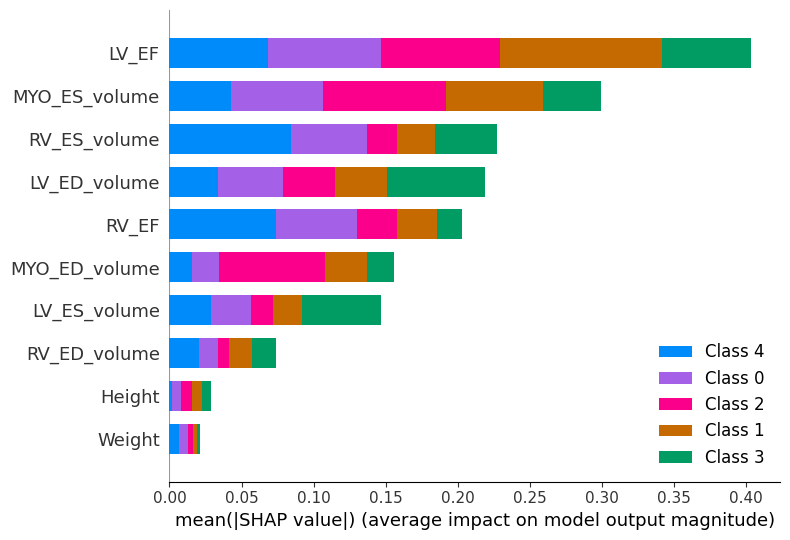

In [50]:
# SHAP plot

shap.summary_plot(shap_values, X_test_all, feature_names=feature_names, plot_type="bar")

### SHAP Interaction plot:

The SHAP interaction plot shows how pairs of volume‑based features jointly influence the model’s predictions. Each cell represents the interaction between two features, with the x‑axis indicating the strength and direction of their combined contribution. Each dot corresponds to a single patient: red indicates a high feature value, blue a low value.

Key observations:
- Strong interactions appear between ED and ES volumes of both ventricles, meaning the model relies on how end‑diastolic and end‑systolic volumes relate to each other.
- LV and MYO volumes also interact, consistent with hypertrophic patterns seen in conditions like HCM.
- These patterns match clinical reality: disorders such as DCM, MINF, and RV‑failure involve abnormalities in both ED and ES volumes rather than isolated features.
- The presence of clear interactions shows that the model does not rely on single features alone but on combinations of anatomical measurements to make robust predictions.

Interpretation of each cell:
- Dots → individual patients
- X‑axis position → how strongly the interaction affects the prediction
- Color → high (red) or low (blue) feature values

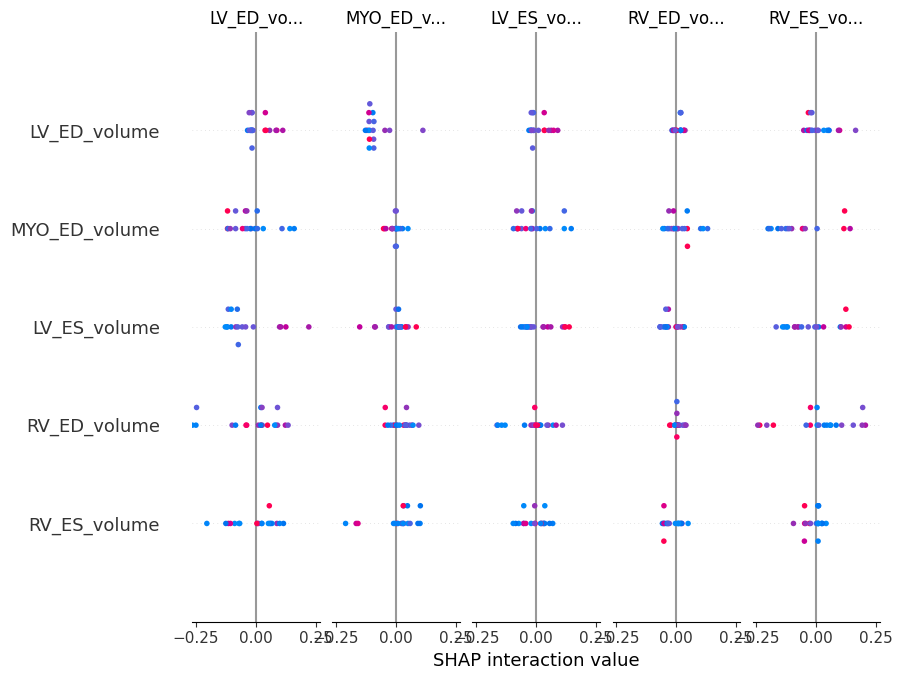

In [47]:
# Shap interaction plot

feature_names = [
    "RV_ED_volume",
    "RV_ES_volume",
    "LV_ED_volume",
    "LV_ES_volume",
    "MYO_ED_volume",
    "MYO_ES_volume",
    "RV_EF",
    "LV_EF",
    "Height",
    "Weight"
]

# SHAP explainer voor Randomforest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_all)

# Summary plot
shap.summary_plot(shap_values, X_test_all, feature_names=feature_names)

## SHAP Dependence Plots

The SHAP dependence plots show how individual features influence the predictions of the RandomForest model.

Each point represents a patient, where the x‑axis is the feature value and the y‑axis is the SHAP value (its contribution to the prediction).

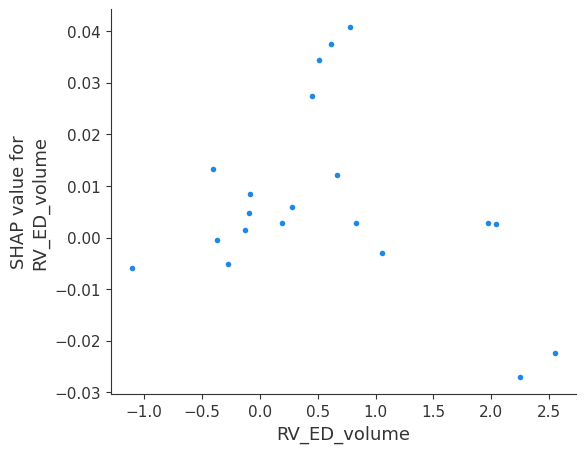

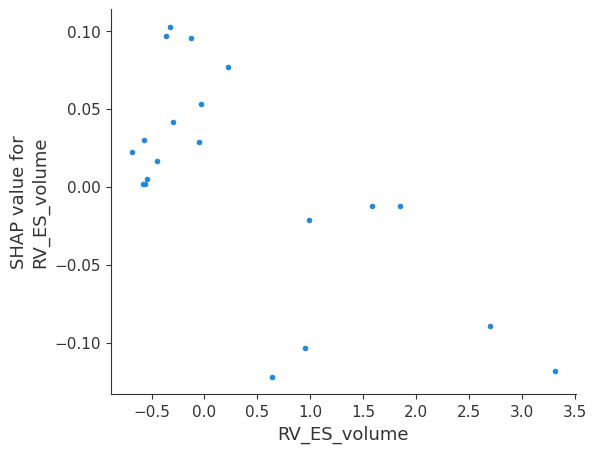

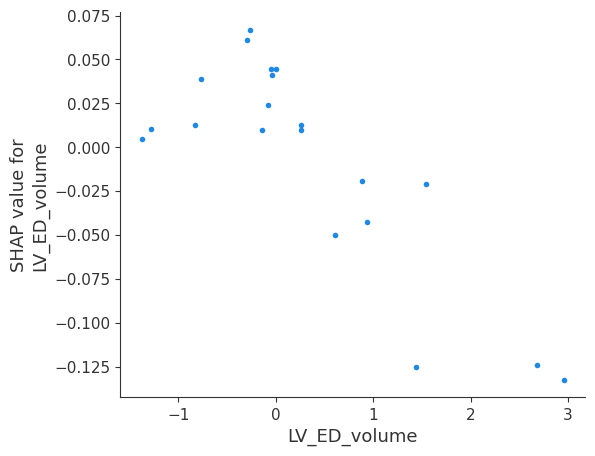

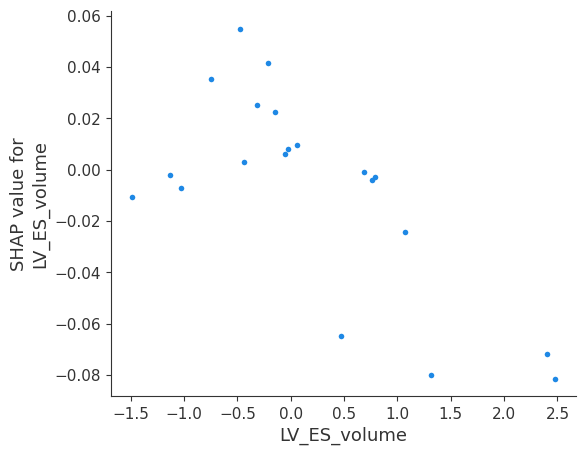

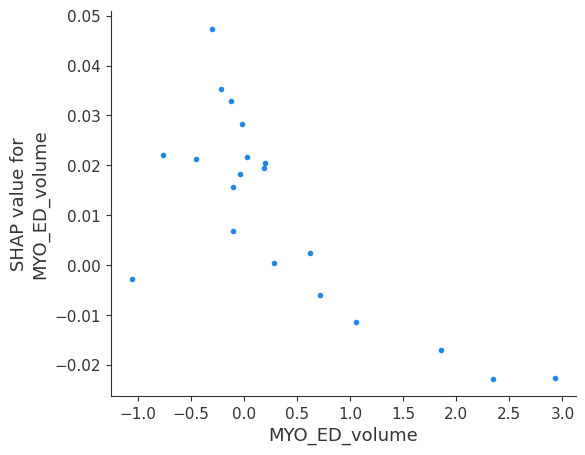

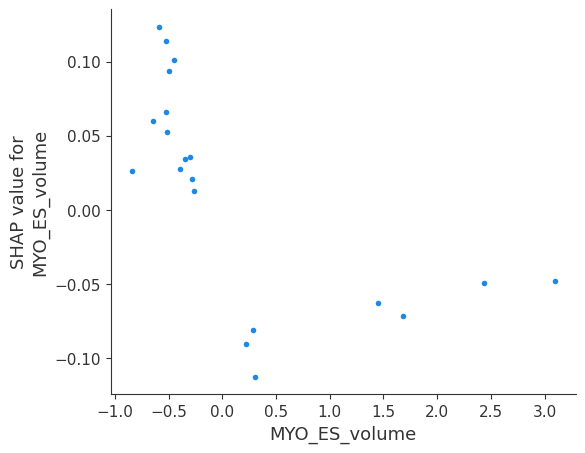

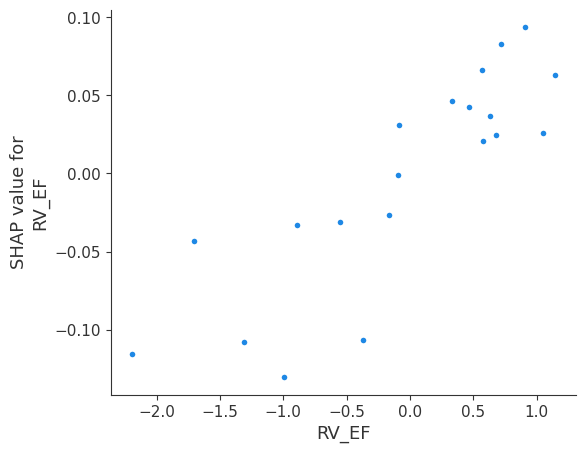

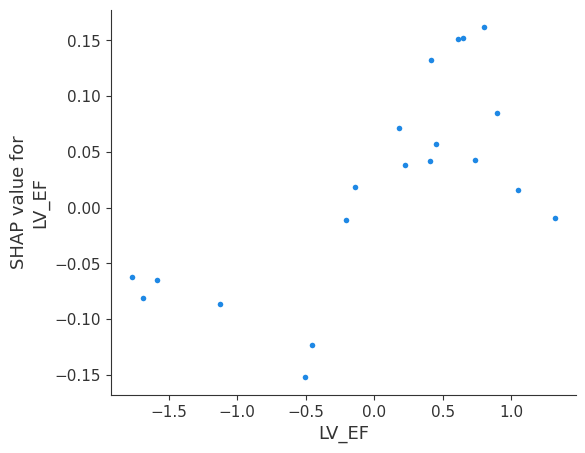

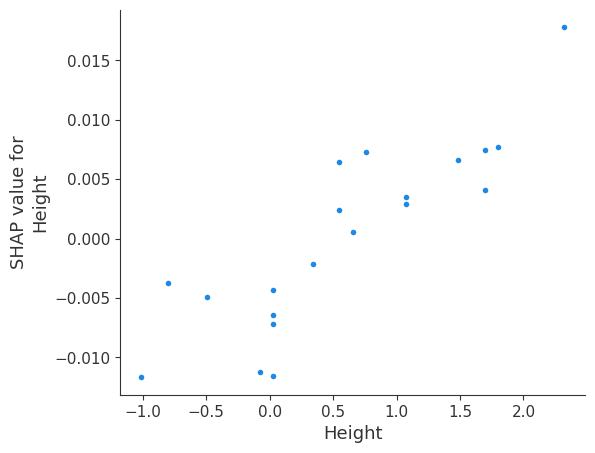

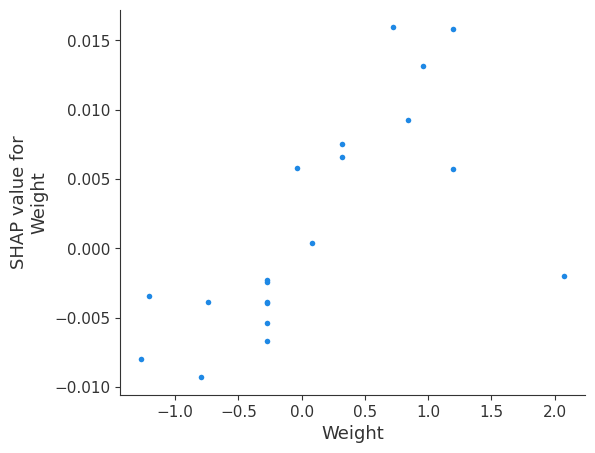

In [48]:
# Shap Dependence plots

shap_array = shap_values
class_idx = 0  # chose the class

for i, feat in enumerate(feature_names):
    shap.dependence_plot(
        i, 
        shap_array[:, :, class_idx],
        X_test_all,
        feature_names=feature_names,
        interaction_index=None
    )

## SHAP dependence bevindingen:

Ejection Fraction (EF)
- RV_EF and LV_EF show a clear positive relationship with SHAP values.
- Higher EF → higher SHAP → higher probability for the predicted class.
- Physiological meaning: better pump function increases the likelihood of a “healthier” or less pathological class.
- Visible in the plots as many points in the upper‑right region.

End‑Systolic Volumes (ESV)
- RV_ES and LV_ES show strong negative SHAP values at higher volumes.
- Higher ESV → negative contribution → lower probability for the predicted class.
- Interpretation: large residual volume after contraction indicates impaired systolic function.
- Visible as clusters in the lower‑right region.

Other features
- EDV and myocardial volumes show more spread and less consistent trends.
- Their effect likely depends on interactions with other variables (e.g., EDV + EF).
- Height and Weight have minimal influence, with SHAP values close to zero.

### Interpretation and physiological meaning

- Positive EF → positive SHAP: a well‑contracting heart increases the likelihood of a favorable class.
- High ES volume → negative SHAP: poor emptying reduces the probability of the predicted class.
- EDV and myocardial volumes: more complex, less linear patterns — consistent with clinical variability across DCM, MINF, HCM, and RV‑failure.

### Implications for model interpretation
- The consistent behavior of EF and ES across folds indicates stable model reasoning.
- EDV and myocardial features vary more, but the overall patterns remain physiologically plausible.
- Height and Weight contribute very little, confirming that the model relies primarily on anatomical cardiac features.

**Conclusion:** 

The SHAP dependence plots confirm that EF and ES volumes are the dominant drivers of the model’s predictions.
EF shows a positive relationship, ES volumes a negative one — fully aligned with expected cardiac physiology. Other features play secondary or interaction‑dependent roles.

## Reliability and Generalization Capacity

During evaluation using a standard train–test split, the Random Forest and CatBoost models achieved an accuracy of 1.00 and a macro F1-score of 1.00. While such perfect performance is theoretically possible, it may also indicate an overly optimistic evaluation, for example due to a small dataset size or a particularly favorable data split.
To assess whether the models truly generalize and do not rely on unintended information (e.g., data leakage), additional validation experiments were performed.

**Label shuffle test: **
- The training labels are randomly shuffled and the model is retrained.
- The model is then evaluated on the original test set.
- This simulates a scenario in which there is no real relationship between input features and target labels.
- The goal is to verify whether the model learns meaningful patterns or instead exploits artifacts in the data (potential data leakage).

**Training process monitoring**

During training of the CatBoost model, the learning progress is monitored at each iteration (log loss over boosting rounds). This provides insight into how the model gradually improves and whether it converges properly when trained on correct labels.

**Interpretation**

If the accuracy obtained with randomly shuffled labels is close to chance level (≈ 0.20 for a 5-class problem), this indicates that the model is not leaking information and is not learning from spurious correlations in the data. In that case, the originally high performance on the true labels is more likely to reflect genuine predictive structure rather than overfitting or data leakage.

In [44]:
y_train_shuffled = np.random.permutation(y_train)

cat.fit(X_train, y_train_shuffled)
pred = cat.predict(X_test)

print("Accuracy met random labels:", accuracy_score(y_test, pred))

Accuracy met random labels: 0.25


In [57]:
y_train_shuffled = np.random.permutation(y_train)

cat.fit(X_train, y_train_shuffled)
pred = cat.predict(X_test)

print("Accuracy met random labels:", accuracy_score(y_test, pred))

Accuracy met random labels: 0.3


In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(cat, X, y, cv=5, scoring='f1_macro')
print("CV scores:", scores)
print("Mean:", scores.mean())

CV scores: [0.8025974  0.84253968 0.94920635 0.69904762 0.84920635]
Mean: 0.8285194805194805


### What the results show

First label shuffle test: accuracy ≈ 0.30
Second label shuffle test: accuracy ≈ 0.15
Cross-validation results: Mean macro F1-score ≈ 0.83 (range: 0.70 – 0.95 across folds)

**Interpretation:**

Both label shuffle results are close to what is expected under random guessing for a 5-class classification problem (≈ 0.20 accuracy). This indicates that when the relationship between features and labels is destroyed, the model performance drops to near-random levels.

This confirms that the model is not exploiting random patterns or artifacts in the data, and that no strong data leakage is present in the pipeline.

In contrast, the original model achieves high performance on the true labels, suggesting that it learns meaningful structure from the input features rather than memorizing noise or dataset-specific biases.

The cross-validation results further support this conclusion, showing relatively stable performance across folds with some expected variation due to dataset size.